In [1]:
#environment setup
import pandas as pd
import numpy as np
import joblib
import optuna
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

train_df = pd.read_csv('../data/processed/train_final.csv')
test_df = pd.read_csv('../data/processed/test_final.csv')
bc_lambda = joblib.load('../models/bc_lambda.pkl')

BEST_WINDOW = 12  # from Phase 5 findings

print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)


def safe_inv_boxcox(y_pred, lmbda, max_reasonable=1500):
    """Safely invert a Box-Cox transform, clipping to avoid domain errors and unrealistic values."""
    if lmbda != 0:
        valid = np.clip(1 + lmbda * y_pred, a_min=1e-6, a_max=None)
        result = valid ** (1 / lmbda)
    else:
        result = np.exp(y_pred)
    return np.clip(result, a_min=0, a_max=max_reasonable)


def evaluate_predictions(y_true, y_pred, model_name):
    """Compute MAE, RMSE, MAPE, and R² for a set of predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}


def create_sequences(X, y, window):
    """Convert tabular data into overlapping sequences of length `window` for RNN input."""
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train shape: (15771, 48) | Test shape: (3930, 48)


In [2]:
#Build feature/target sets (tabular, for XGBoost)

feature_cols = [c for c in train_df.columns if c not in ['date', 'Appliances', 'Appliances_bc']]

X_train = train_df[feature_cols]
y_train = train_df['Appliances_bc']
X_test = test_df[feature_cols]
y_test_actual = test_df['Appliances']

print("Features:", len(feature_cols))

Features: 45


In [3]:
#Load prior baseline/DL results (for before/after comparison later)

baseline_results = pd.read_csv('../data/processed/baseline_results.csv')
dl_results_df = pd.read_csv('../data/processed/dl_results.csv')

print(baseline_results)
print(dl_results_df)

               Model        MAE        RMSE       MAPE        R2
0              Naive  26.246819   65.747028  21.898901  0.449627
1  Linear Regression  39.004480  131.875555  26.403592 -1.214287
2      Random Forest  21.467393   52.669068  16.502867  0.646803
3            XGBoost  19.286535   48.798904  15.277149  0.696803
     Model        MAE       RMSE       MAPE        R2
0     LSTM  28.281775  68.642078  22.916919  0.388753
1      GRU  32.139880  82.197495  25.676301  0.123497
2  CNN-GRU  31.489904  73.430912  25.237913  0.300490


In [4]:
#Optuna: tune XGBoost

def objective_xgb(trial):
    """Optuna objective for XGBoost hyperparameter search using time-series CV."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }

    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, pred))

    return np.mean(scores)

study_xgb = optuna.create_study(direction='minimize', study_name='xgb_tuning')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print("Best XGBoost params:", study_xgb.best_params)
print("Best CV MAE (Box-Cox space):", study_xgb.best_value)

[I 2026-07-19 20:27:28,605] A new study created in memory with name: xgb_tuning
Best trial: 0. Best value: 0.0223064:   3%|▎         | 1/30 [00:21<10:29, 21.71s/it]

[I 2026-07-19 20:27:50,305] Trial 0 finished with value: 0.022306437098892438 and parameters: {'n_estimators': 365, 'max_depth': 10, 'learning_rate': 0.10738379804638151, 'subsample': 0.6177186431132018, 'colsample_bytree': 0.6537985594470426, 'min_child_weight': 3}. Best is trial 0 with value: 0.022306437098892438.


Best trial: 1. Best value: 0.0202844:   7%|▋         | 2/30 [00:24<04:52, 10.45s/it]

[I 2026-07-19 20:27:52,876] Trial 1 finished with value: 0.02028440278859803 and parameters: {'n_estimators': 153, 'max_depth': 5, 'learning_rate': 0.024000975801239506, 'subsample': 0.9952616195816354, 'colsample_bytree': 0.6795652122684726, 'min_child_weight': 7}. Best is trial 1 with value: 0.02028440278859803.


Best trial: 2. Best value: 0.0189287:  10%|█         | 3/30 [00:39<05:44, 12.76s/it]

...

[I 2026-07-19 20:32:54,577] Trial 27 finished with value: 0.019120071183726547 and parameters: {'n_estimators': 412, 'max_depth': 9, 'learning_rate': 0.048625413024488605, 'subsample': 0.867945740970222, 'colsample_bytree': 0.9845836311474019, 'min_child_weight': 10}. Best is trial 26 with value: 0.018854701599407674.


Best trial: 26. Best value: 0.0188547:  97%|█████████▋| 29/30 [05:46<00:16, 16.63s/it]

[I 2026-07-19 20:33:15,411] Trial 28 finished with value: 0.020369920663724315 and parameters: {'n_estimators': 447, 'max_depth': 10, 'learning_rate': 0.08098792772601682, 'subsample': 0.6869741372310493, 'colsample_bytree': 0.9567246036301775, 'min_child_weight': 8}. Best is trial 26 with value: 0.018854701599407674.


Best trial: 26. Best value: 0.0188547: 100%|██████████| 30/30 [06:08<00:00, 12.29s/it]

[I 2026-07-19 20:33:37,161] Trial 29 finished with value: 0.020109023373942776 and parameters: {'n_estimators': 499, 'max_depth': 10, 'learning_rate': 0.1112884897431442, 'subsample': 0.9772763829161624, 'colsample_bytree': 0.8501695421476644, 'min_child_weight': 9}. Best is trial 26 with value: 0.018854701599407674.
Best XGBoost params: {'n_estimators': 415, 'max_depth': 9, 'learning_rate': 0.027254568594193486, 'subsample': 0.9722348355713633, 'colsample_bytree': 0.9697175164202116, 'min_child_weight': 9}
Best CV MAE (Box-Cox space): 0.018854701599407674


In [5]:
#Retrain XGBoost with best params, evaluate on real test set

best_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42)
best_xgb.fit(X_train, y_train)
pred_actual = safe_inv_boxcox(best_xgb.predict(X_test), bc_lambda)

tuned_xgb_metrics = evaluate_predictions(y_test_actual, pred_actual, 'XGBoost_Tuned')
print("Tuned XGBoost:", tuned_xgb_metrics)
print("Original XGBoost:", baseline_results[baseline_results['Model']=='XGBoost'].to_dict('records')[0])

joblib.dump(best_xgb, '../models/xgb_tuned.pkl')

Tuned XGBoost: {'Model': 'XGBoost_Tuned', 'MAE': 17.914650167493416, 'RMSE': np.float64(44.86144363123109), 'MAPE': np.float64(14.611852494575903), 'R2': 0.7437571706446189}
Original XGBoost: {'Model': 'XGBoost', 'MAE': 19.2865354070943, 'RMSE': 48.7989044873842, 'MAPE': 15.277148960197916, 'R2': 0.6968026676410302}


['../models/xgb_tuned.pkl']

In [6]:
#LSTM Optimization


In [7]:
#Prepare sequence data for LSTM tuning

X_train_raw = train_df[feature_cols].values
y_train_raw = train_df['Appliances_bc'].values
X_test_raw = test_df[feature_cols].values
y_test_bc_raw = test_df['Appliances_bc'].values
y_test_actual_full = test_df['Appliances'].values

Xs, ys = create_sequences(X_train_raw, y_train_raw, BEST_WINDOW)
Xte, yte_bc = create_sequences(X_test_raw, y_test_bc_raw, BEST_WINDOW)
yte_actual = y_test_actual_full[BEST_WINDOW:]

print("Sequence shapes:", Xs.shape, Xte.shape)

Sequence shapes: (15759, 12, 45) (3918, 12, 45)


In [8]:
#Optuna: tune LSTM

def objective_lstm(trial):
    """Optuna objective for LSTM hyperparameter search."""
    units = trial.suggest_int('units', 32, 128)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(Xs.shape[1], Xs.shape[2])),
        LSTM(units//2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='huber')

    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    history = model.fit(Xs, ys, validation_split=0.15, epochs=30, batch_size=batch_size,
                         callbacks=[es], verbose=0)
    return min(history.history['val_loss'])

study_lstm = optuna.create_study(direction='minimize', study_name='lstm_tuning')
study_lstm.optimize(objective_lstm, n_trials=20, show_progress_bar=True)

print("Best LSTM params:", study_lstm.best_params)

[I 2026-07-19 20:52:37,487] A new study created in memory with name: lstm_tuning
  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 0. Best value: 0.000659973:   5%|▌         | 1/20 [01:55<36:31, 115.37s/it]

[I 2026-07-19 20:54:32,852] Trial 0 finished with value: 0.0006599734770134091 and parameters: {'units': 114, 'lr': 0.003384665856597254, 'batch_size': 16}. Best is trial 0 with value: 0.0006599734770134091.


Best trial: 0. Best value: 0.000659973:  10%|█         | 2/20 [02:44<22:58, 76.59s/it] 

[I 2026-07-19 20:55:22,304] Trial 1 finished with value: 0.0006607893737964332 and parameters: {'units': 63, 'lr': 0.0043425531496662445, 'batch_size': 32}. Best is trial 0 with value: 0.0006599734770134091.


...

[I 2026-07-19 21:22:11,087] Trial 17 finished with value: 0.0005588367930613458 and parameters: {'units': 100, 'lr': 0.000736733606777489, 'batch_size': 64}. Best is trial 5 with value: 0.0005131326615810394.


Best trial: 5. Best value: 0.000513133:  95%|█████████▌| 19/20 [31:03<01:28, 88.06s/it]

[I 2026-07-19 21:23:40,539] Trial 18 finished with value: 0.0005299547337926924 and parameters: {'units': 124, 'lr': 0.0008116240193739168, 'batch_size': 64}. Best is trial 5 with value: 0.0005131326615810394.


Best trial: 5. Best value: 0.000513133: 100%|██████████| 20/20 [32:25<00:00, 97.26s/it]

[I 2026-07-19 21:25:02,631] Trial 19 finished with value: 0.0007368514779955149 and parameters: {'units': 108, 'lr': 0.009796679707109573, 'batch_size': 32}. Best is trial 5 with value: 0.0005131326615810394.
Best LSTM params: {'units': 114, 'lr': 0.0018666909767093539, 'batch_size': 64}


In [9]:
#Retrain LSTM with best params

best_params = study_lstm.best_params
final_lstm = Sequential([
    LSTM(best_params['units'], return_sequences=True, input_shape=(Xs.shape[1], Xs.shape[2])),
    LSTM(best_params['units']//2),
    Dense(16, activation='relu'),
    Dense(1)
])
final_lstm.compile(optimizer=Adam(learning_rate=best_params['lr']), loss='huber')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_final_lstm = final_lstm.fit(Xs, ys, validation_split=0.15, epochs=60,
                                     batch_size=best_params['batch_size'], callbacks=[es], verbose=1)

pred_actual = safe_inv_boxcox(final_lstm.predict(Xte, verbose=0).flatten(), bc_lambda)
tuned_lstm_metrics = evaluate_predictions(yte_actual, pred_actual, 'LSTM_Tuned')
print("Tuned LSTM:", tuned_lstm_metrics)
print("Original LSTM:", dl_results_df[dl_results_df['Model']=='LSTM'].to_dict('records')[0])

final_lstm.save('../models/lstm_tuned.h5')

Epoch 1/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0127 - val_loss: 9.7541e-04
Epoch 2/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0011 - val_loss: 7.1807e-04
Epoch 3/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 9.9804e-04 - val_loss: 6.6501e-04
Epoch 4/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 9.6023e-04 - val_loss: 6.2788e-04
Epoch 5/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 9.3757e-04 - val_loss: 6.2273e-04
Epoch 6/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 8.9362e-04 - val_loss: 8.0093e-04
Epoch 7/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 8.6821e-04 - val_loss: 6.5974e-04
Epoch 8/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 8.7229e-04 - val_loss: 7.1229e-04
Epoch 9/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 8.4801e-04 - val_loss: 6.8905e-04
Epoch 10/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 8.3502e-04 - val_loss: 8.3393e-04
Epoch 11/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - l

Tuned LSTM: {'Model': 'LSTM_Tuned', 'MAE': 29.266150190143673, 'RMSE': np.float64(67.0165640125755), 'MAPE': np.float64(24.24239316667829), 'R2': 0.41735998447550193}
Original LSTM: {'Model': 'LSTM', 'MAE': 28.281775057956686, 'RMSE': 68.64207773200053, 'MAPE': 22.916918687317324, 'R2': 0.3887528671367728}


              Model        MAE       RMSE       MAPE        R2
0  XGBoost (before)  19.286535  48.798904  15.277149  0.696803
1     XGBoost_Tuned  17.914650  44.861444  14.611852  0.743757
2     LSTM (before)  28.281775  68.642078  22.916919  0.388753
3        LSTM_Tuned  29.266150  67.016564  24.242393  0.417360


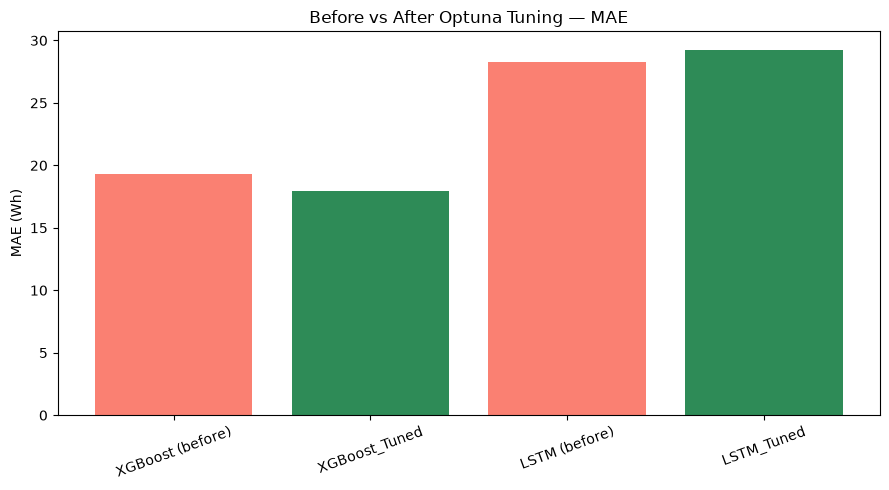

In [10]:
#Before/after comparison table + plot

before_after = pd.DataFrame([
    {**baseline_results[baseline_results['Model']=='XGBoost'].iloc[0].to_dict()},
    tuned_xgb_metrics,
    {**dl_results_df[dl_results_df['Model']=='LSTM'].iloc[0].to_dict()},
    tuned_lstm_metrics,
])
before_after.loc[0, 'Model'] = 'XGBoost (before)'
before_after.loc[2, 'Model'] = 'LSTM (before)'

print(before_after)
before_after.to_csv('../data/processed/optimization_comparison.csv', index=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,5))
plt.bar(before_after['Model'], before_after['MAE'], color=['salmon','seagreen','salmon','seagreen'])
plt.title('Before vs After Optuna Tuning — MAE')
plt.ylabel('MAE (Wh)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../reports/optimization_before_after.png', dpi=150)
plt.show()

In [11]:
#Save Optuna study results 
study_xgb.trials_dataframe().to_csv('../data/processed/optuna_xgb_trials.csv', index=False)
study_lstm.trials_dataframe().to_csv('../data/processed/optuna_lstm_trials.csv', index=False)

In [12]:
# Exclude engineered lag/rolling columns — let LSTM learn temporal patterns from the raw sequence itself
lag_roll_cols = [c for c in feature_cols if 'lag' in c or 'roll' in c]
raw_seq_cols = [c for c in feature_cols if c not in lag_roll_cols]

print(f"Using {len(raw_seq_cols)} raw features (excluded {len(lag_roll_cols)} lag/rolling columns)")

X_train_raw2 = train_df[raw_seq_cols].values
X_test_raw2 = test_df[raw_seq_cols].values

Xs2, ys2 = create_sequences(X_train_raw2, y_train_raw, BEST_WINDOW)
Xte2, yte_bc2 = create_sequences(X_test_raw2, y_test_bc_raw, BEST_WINDOW)
yte_actual2 = y_test_actual_full[BEST_WINDOW:]

lstm_raw = Sequential([
    LSTM(114, return_sequences=True, input_shape=(Xs2.shape[1], Xs2.shape[2])),
    LSTM(57),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_raw.compile(optimizer=Adam(learning_rate=0.00187), loss='huber')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lstm_raw.fit(Xs2, ys2, validation_split=0.15, epochs=60, batch_size=64, callbacks=[es], verbose=1)

pred_actual2 = safe_inv_boxcox(lstm_raw.predict(Xte2, verbose=0).flatten(), bc_lambda)
metrics_raw = evaluate_predictions(yte_actual2, pred_actual2, 'LSTM_RawFeatures')
print(metrics_raw)

Using 37 raw features (excluded 8 lag/rolling columns)
Epoch 1/60


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0162 - val_loss: 0.0013
Epoch 2/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 3/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 5/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 7/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 8/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 11/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 12/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/ste

In [13]:
#GBoost v2 — wider search (regularization added, more trials)
def objective_xgb_v2(trial):
    """Expanded Optuna objective for XGBoost: adds regularization params, wider ranges, more trials."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, pred))
    return np.mean(scores)

study_xgb_v2 = optuna.create_study(direction='minimize', study_name='xgb_tuning_v2')
study_xgb_v2.optimize(objective_xgb_v2, n_trials=60, show_progress_bar=True)

print("Best v2 XGBoost params:", study_xgb_v2.best_params)
print("Best v2 CV MAE:", study_xgb_v2.best_value)


[I 2026-07-19 23:13:29,230] A new study created in memory with name: xgb_tuning_v2
Best trial: 0. Best value: 0.0302196:   2%|▏         | 1/60 [00:00<00:55,  1.07it/s]

[I 2026-07-19 23:13:30,162] Trial 0 finished with value: 0.030219594122193143 and parameters: {'n_estimators': 229, 'max_depth': 3, 'learning_rate': 0.01022402955224405, 'subsample': 0.7198305834437808, 'colsample_bytree': 0.8475037574271497, 'min_child_weight': 6, 'gamma': 3.5760811510148462, 'reg_alpha': 2.3854545427376705, 'reg_lambda': 3.7924177190986965}. Best is trial 0 with value: 0.030219594122193143.


Best trial: 1. Best value: 0.0257531:   3%|▎         | 2/60 [00:02<01:17,  1.34s/it]

[I 2026-07-19 23:13:31,780] Trial 1 finished with value: 0.02575308448136046 and parameters: {'n_estimators': 557, 'max_depth': 3, 'learning_rate': 0.2539927267512154, 'subsample': 0.8966466996009659, 'colsample_bytree': 0.6219307497341185, 'min_child_weight': 3, 'gamma': 0.5968928515529498, 'reg_alpha': 3.1001659551434253, 'reg_lambda': 3.3404061844825836}. Best is trial 1 with value: 0.02575308448136046.


Best trial: 1. Best value: 0.0257531:   5%|▌         | 3/60 [00:03<01:07,  1.18s/it]

...

[I 2026-07-19 23:14:40,630] Trial 57 finished with value: 0.02623794457942435 and parameters: {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.0877462758304197, 'subsample': 0.6980760450013286, 'colsample_bytree': 0.5021805929316334, 'min_child_weight': 12, 'gamma': 1.1035281673566042, 'reg_alpha': 3.7312258830219878, 'reg_lambda': 1.1413057698819637}. Best is trial 15 with value: 0.022171765755990447.


Best trial: 15. Best value: 0.0221718:  98%|█████████▊| 59/60 [01:12<00:01,  1.13s/it]

[I 2026-07-19 23:14:42,068] Trial 58 finished with value: 0.02477808938665481 and parameters: {'n_estimators': 261, 'max_depth': 9, 'learning_rate': 0.07397448583697372, 'subsample': 0.6743919437532753, 'colsample_bytree': 0.7230681075328372, 'min_child_weight': 13, 'gamma': 0.674924540897944, 'reg_alpha': 1.365887501538165, 'reg_lambda': 0.5115893930221814}. Best is trial 15 with value: 0.022171765755990447.


Best trial: 15. Best value: 0.0221718: 100%|██████████| 60/60 [01:14<00:00,  1.24s/it]

[I 2026-07-19 23:14:43,492] Trial 59 finished with value: 0.02445634663382811 and parameters: {'n_estimators': 236, 'max_depth': 6, 'learning_rate': 0.046807969574885845, 'subsample': 0.7308741545224664, 'colsample_bytree': 0.7759701255042358, 'min_child_weight': 10, 'gamma': 0.3981571894312746, 'reg_alpha': 4.802617215828873, 'reg_lambda': 2.1823988162508927}. Best is trial 15 with value: 0.022171765755990447.
Best v2 XGBoost params: {'n_estimators': 204, 'max_depth': 7, 'learning_rate': 0.08043717128688305, 'subsample': 0.7652347843853824, 'colsample_bytree': 0.5362810649853661, 'min_child_weight': 15, 'gamma': 0.0034893352422539214, 'reg_alpha': 4.279246320850233, 'reg_lambda': 1.1880981720038666}
Best v2 CV MAE: 0.022171765755990447


In [14]:
best_xgb_v2 = xgb.XGBRegressor(**study_xgb_v2.best_params, random_state=42)
best_xgb_v2.fit(X_train, y_train)
pred_actual = safe_inv_boxcox(best_xgb_v2.predict(X_test), bc_lambda)

tuned_xgb_v2_metrics = evaluate_predictions(y_test_actual, pred_actual, 'XGBoost_Tuned_v2')
print(tuned_xgb_v2_metrics)
print("Previous tuned XGBoost:", tuned_xgb_metrics)

joblib.dump(best_xgb_v2, '../models/xgb_tuned_v2.pkl')

{'Model': 'XGBoost_Tuned_v2', 'MAE': 23.1388637139661, 'RMSE': np.float64(60.92521440382339), 'MAPE': np.float64(17.479261366770015), 'R2': 0.5273938557680502}
Previous tuned XGBoost: {'Model': 'XGBoost_Tuned', 'MAE': 17.914650167493416, 'RMSE': np.float64(44.86144363123109), 'MAPE': np.float64(14.611852494575903), 'R2': 0.7437571706446189}


['../models/xgb_tuned_v2.pkl']

In [ ]:
#LSTM v2 — wider search (layers, units, window, lr, batch size jointly)
def objective_lstm_v2(trial):
    """
    Expanded Optuna objective for LSTM: jointly searches window length,
    number of layers, units per layer, learning rate, and batch size.
    """
    window = trial.suggest_categorical('window', [6, 12, 18, 24])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = trial.suggest_int('units', 32, 160)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    Xs_t, ys_t = create_sequences(X_train_raw, y_train_raw, window)

    layers = []
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)  # only last LSTM layer returns a single vector
        if i == 0:
            layers.append(LSTM(units, return_sequences=return_seq,
                                input_shape=(Xs_t.shape[1], Xs_t.shape[2])))
        else:
            units = max(units // 2, 8)  # taper layer sizes
            layers.append(LSTM(units, return_sequences=return_seq))
    layers += [Dense(16, activation='relu'), Dense(1)]

    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=lr), loss='huber')

    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    history = model.fit(Xs_t, ys_t, validation_split=0.15, epochs=30, batch_size=batch_size,
                         callbacks=[es], verbose=0)
    return min(history.history['val_loss'])

study_lstm_v2 = optuna.create_study(direction='minimize', study_name='lstm_tuning_v2')
study_lstm_v2.optimize(objective_lstm_v2, n_trials=25, show_progress_bar=True)

print("Best v2 LSTM params:", study_lstm_v2.best_params)

[I 2026-07-19 23:16:36,856] A new study created in memory with name: lstm_tuning_v2
  0%|          | 0/25 [00:00<?, ?it/s]C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 0. Best value: 0.000600841:   4%|▍         | 1/25 [01:42<41:10, 102.92s/it]

[I 2026-07-19 23:18:19,775] Trial 0 finished with value: 0.000600840721745044 and parameters: {'window': 24, 'n_layers': 2, 'units': 87, 'lr': 0.003685752370111333, 'batch_size': 64}. Best is trial 0 with value: 0.000600840721745044.


Best trial: 0. Best value: 0.000600841:   8%|▊         | 2/25 [04:13<50:11, 130.95s/it]

[I 2026-07-19 23:20:50,354] Trial 1 finished with value: 0.0006498776492662728 and parameters: {'window': 24, 'n_layers': 2, 'units': 126, 'lr': 0.0034475887792683167, 'batch_size': 16}. Best is trial 0 with value: 0.000600840721745044.


Best trial: 2. Best value: 0.000529416:  12%|█▏        | 3/25 [12:31<1:49:29, 298.60s/it]

[I 2026-07-19 23:29:08,442] Trial 2 finished with value: 0.0005294164293445647 and parameters: {'window': 24, 'n_layers': 3, 'units': 147, 'lr': 0.00016742778839652043, 'batch_size': 16}. Best is trial 2 with value: 0.0005294164293445647.


Best trial: 2. Best value: 0.000529416:  16%|█▌        | 4/25 [16:30<1:36:12, 274.87s/it]

[I 2026-07-19 23:33:06,946] Trial 3 finished with value: 0.000543949892744422 and parameters: {'window': 24, 'n_layers': 3, 'units': 81, 'lr': 0.0007799446358664439, 'batch_size': 16}. Best is trial 2 with value: 0.0005294164293445647.
